In [17]:
# NumPy y Pandas

# 1. importar librerias

import numpy as np
import pandas as pd


# 2. crear array aleatorio

array = np.random.randint(1, 1001, 100)

df = pd.DataFrame(
    array,
    columns=["Valores"]
)

print("DATOS ORIGINALES")
print(df.head(10))


# 3. identificar multiplos de 3 o de 5

condicion = (
    (df["Valores"] % 3 == 0) |
    (df["Valores"] % 5 == 0)
)


# 4. calcular media de los valores validos

media = df.loc[
    ~condicion,
    "Valores"
].mean()

print("\nMedia utilizada:", round(media, 2))


# 5. reemplazar valores

df["Valores"] = df["Valores"].astype(float)

df.loc[
    condicion,
    "Valores"
] = media


# 6. mostrar resultado final

print("\nDATOS MODIFICADOS")
print(df.head(20))

DATOS ORIGINALES
   Valores
0      632
1      926
2       79
3      835
4      774
5      721
6      817
7      732
8      595
9       22

Media utilizada: 554.81

DATOS MODIFICADOS
       Valores
0   632.000000
1   926.000000
2    79.000000
3   554.814815
4   554.814815
5   721.000000
6   817.000000
7   554.814815
8   554.814815
9    22.000000
10  946.000000
11  893.000000
12  554.814815
13  182.000000
14  554.814815
15  737.000000
16  554.814815
17  281.000000
18  554.814815
19  554.814815


In [13]:
# NumPy y Pandas

# 1. importar librerias

import numpy as np
import pandas as pd


# 2. crear dataframe con salarios

salarios = np.random.randint(1000, 10000, 100)

df = pd.DataFrame(
    salarios,
    columns=["Salario"]
)

# agregar outliers

df.loc[0, "Salario"] = 50000
df.loc[1, "Salario"] = 60000
df.loc[2, "Salario"] = 200
df.loc[3, "Salario"] = 300

print("SALARIOS ORIGINALES")
print(df.head(10))


# 3. calcular IQR

Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# 4. identificar outliers

outliers = df[
    (df["Salario"] < limite_inferior) |
    (df["Salario"] > limite_superior)
]

print("\nOUTLIERS DETECTADOS")
print(outliers)


# 5. calcular percentiles

p5 = df["Salario"].quantile(0.05)
p95 = df["Salario"].quantile(0.95)


# 6. reemplazar outliers

df.loc[df["Salario"] < limite_inferior, "Salario"] = p5

df.loc[df["Salario"] > limite_superior, "Salario"] = p95


# 7. mostrar resultado final

print("\nSALARIOS CORREGIDOS")
print(df.head(10))

SALARIOS ORIGINALES
   Salario
0    50000
1    60000
2      200
3      300
4     2680
5     9286
6     3465
7     4230
8     1920
9     5769

OUTLIERS DETECTADOS
   Salario
0    50000
1    60000

SALARIOS CORREGIDOS
   Salario
0  9836.35
1  9836.35
2   200.00
3   300.00
4  2680.00
5  9286.00
6  3465.00
7  4230.00
8  1920.00
9  5769.00


/tmp/ipykernel_8290/2292071331.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1444.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["Salario"] < limite_inferior, "Salario"] = p5


In [12]:
# Pandas

# 1. importar pandas

import pandas as pd


# 2. crear dataframe

data = {
    "Producto": ["Producto A", "Producto B", "Producto C"],
    "Enero": [150, 200, 180],
    "Febrero": [170, 220, 190],
    "Marzo": [160, 210, 200]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. transformar a formato largo

df_largo = pd.melt(
    df,
    id_vars=["Producto"],
    value_vars=["Enero", "Febrero", "Marzo"],
    var_name="Mes",
    value_name="Ventas"
)


# 4. mostrar resultado final

print("\nDATAFRAME EN FORMATO LARGO")
print(df_largo)

DATAFRAME ORIGINAL
     Producto  Enero  Febrero  Marzo
0  Producto A    150      170    160
1  Producto B    200      220    210
2  Producto C    180      190    200

DATAFRAME EN FORMATO LARGO
     Producto      Mes  Ventas
0  Producto A    Enero     150
1  Producto B    Enero     200
2  Producto C    Enero     180
3  Producto A  Febrero     170
4  Producto B  Febrero     220
5  Producto C  Febrero     190
6  Producto A    Marzo     160
7  Producto B    Marzo     210
8  Producto C    Marzo     200


In [11]:
# Pandas

# 1. importar pandas

import pandas as pd


# 2. crear dataframe

data = {
    "Empleado": ["Ana", "Juan", "Pedro", "Maria", "Carlos", "Laura"],
    "Departamento": ["Ventas", "Ventas", "Ventas", "Produccion", "Produccion", "Produccion"],
    "Proyecto": ["A", "B", "C", "A", "B", "C"],
    "Horas": [40, 30, 50, 60, 20, 40]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. calcular porcentaje de horas por departamento

df["Porcentaje_Depto"] = df.groupby("Departamento")["Horas"].transform(
    lambda x: (x / x.sum()) * 100
)


# 4. redondear porcentaje

df["Porcentaje_Depto"] = df["Porcentaje_Depto"].round(2)


# 5. mostrar resultado final

print("\nPORCENTAJE DE HORAS POR DEPARTAMENTO")
print(df)

DATAFRAME ORIGINAL
  Empleado Departamento Proyecto  Horas
0      Ana       Ventas        A     40
1     Juan       Ventas        B     30
2    Pedro       Ventas        C     50
3    Maria   Produccion        A     60
4   Carlos   Produccion        B     20
5    Laura   Produccion        C     40

PORCENTAJE DE HORAS POR DEPARTAMENTO
  Empleado Departamento Proyecto  Horas  Porcentaje_Depto
0      Ana       Ventas        A     40             33.33
1     Juan       Ventas        B     30             25.00
2    Pedro       Ventas        C     50             41.67
3    Maria   Produccion        A     60             50.00
4   Carlos   Produccion        B     20             16.67
5    Laura   Produccion        C     40             33.33


In [10]:
# Pandas

# 1. importar librerias

import pandas as pd


# 2. crear serie temporal

fechas = [
    "2026-01-01",
    "2026-01-03",
    "2026-01-04",
    "2026-01-07",
    "2026-01-10",
    "2026-01-12",
    "2026-01-15"
]

valores = [10, 20, 30, 50, 80, 100, 120]

serie = pd.Series(
    valores,
    index=pd.to_datetime(fechas)
)

print("SERIE ORIGINAL")
print(serie)


# 3. crear rango completo de fechas

rango_fechas = pd.date_range(
    start="2026-01-01",
    end="2026-01-15"
)


# 4. completar fechas faltantes

serie_completa = serie.reindex(rango_fechas)


# 5. interpolar valores faltantes

serie_completa = serie_completa.interpolate(method="linear")


# 6. convertir a dataframe

df = pd.DataFrame(
    serie_completa,
    columns=["Valor"]
)


# 7. mostrar resultado final

print("\nSERIE COMPLETA INTERPOLADA")
print(df)

SERIE ORIGINAL
2026-01-01     10
2026-01-03     20
2026-01-04     30
2026-01-07     50
2026-01-10     80
2026-01-12    100
2026-01-15    120
dtype: int64

SERIE COMPLETA INTERPOLADA
                 Valor
2026-01-01   10.000000
2026-01-02   15.000000
2026-01-03   20.000000
2026-01-04   30.000000
2026-01-05   36.666667
2026-01-06   43.333333
2026-01-07   50.000000
2026-01-08   60.000000
2026-01-09   70.000000
2026-01-10   80.000000
2026-01-11   90.000000
2026-01-12  100.000000
2026-01-13  106.666667
2026-01-14  113.333333
2026-01-15  120.000000


In [9]:
# Pandas

# 1. importar librerias

import pandas as pd


# 2. crear dataframe

data = {
    "Categoria_Producto": [
        "Electronica", "Electronica", "Ropa", "Ropa",
        "Hogar", "Hogar", "Electronica", "Ropa",
        "Hogar", "Electronica", "Ropa", "Hogar"
    ],

    "Metodo_Pago": [
        "Tarjeta", "Efectivo", "Tarjeta", "Transferencia",
        "Tarjeta", "Efectivo", "Transferencia", "Tarjeta",
        "Transferencia", "Tarjeta", "Efectivo", "Tarjeta"
    ],

    "Satisfecho": [
        "Si", "No", "Si", "Si",
        "No", "Si", "Si", "No",
        "Si", "Si", "No", "Si"
    ]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. crear tabla cruzada

tabla = pd.crosstab(
    [df["Categoria_Producto"], df["Metodo_Pago"]],
    df["Satisfecho"],
    normalize="index"
) * 100


# 4. redondear porcentajes

tabla = tabla.round(2)


# 5. reiniciar indice

tabla = tabla.reset_index()


# 6. mostrar resultado final

print("\nPORCENTAJE DE SATISFACCION")
print(tabla)

DATAFRAME ORIGINAL
   Categoria_Producto    Metodo_Pago Satisfecho
0         Electronica        Tarjeta         Si
1         Electronica       Efectivo         No
2                Ropa        Tarjeta         Si
3                Ropa  Transferencia         Si
4               Hogar        Tarjeta         No
5               Hogar       Efectivo         Si
6         Electronica  Transferencia         Si
7                Ropa        Tarjeta         No
8               Hogar  Transferencia         Si
9         Electronica        Tarjeta         Si
10               Ropa       Efectivo         No
11              Hogar        Tarjeta         Si

PORCENTAJE DE SATISFACCION
Satisfecho Categoria_Producto    Metodo_Pago     No     Si
0                 Electronica       Efectivo  100.0    0.0
1                 Electronica        Tarjeta    0.0  100.0
2                 Electronica  Transferencia    0.0  100.0
3                       Hogar       Efectivo    0.0  100.0
4                       Hogar     

In [8]:
# Pandas

# 1. importar pandas

import pandas as pd


# 2. crear dataframe de usuarios

df_usuarios = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Ana", "Juan", "Pedro", "Maria", "Luis"],
    "Pais": ["Colombia", "Mexico", "Argentina", "Colombia", "Mexico"]
})


# 3. crear dataframe de transacciones

df_transacciones = pd.DataFrame({
    "ID_Transaccion": [101, 102, 103, 104, 105, 106, 107],
    "ID_Usuario": [1, 2, 3, 4, 5, 1, 2],
    "Monto": [500, 1200, 300, 2500, 1800, 900, 1500],
    "Fecha": [
        "2026-01-05",
        "2026-01-08",
        "2026-01-10",
        "2026-01-12",
        "2026-01-15",
        "2026-01-18",
        "2026-01-20"
    ]
})


# 4. calcular promedio global

promedio = df_transacciones["Monto"].mean()

print("Promedio global:", round(promedio, 2))


# 5. filtrar transacciones superiores al promedio

transacciones_altas = df_transacciones[
    df_transacciones["Monto"] > promedio
]


# 6. unir dataframes

resultado = pd.merge(
    df_usuarios,
    transacciones_altas,
    left_on="ID",
    right_on="ID_Usuario"
)


# 7. conservar solo colombia y mexico

resultado = resultado[
    resultado["Pais"].isin(["Colombia", "Mexico"])
]


# 8. mostrar resultado final

print(resultado)

Promedio global: 1242.86
   ID Nombre      Pais  ID_Transaccion  ID_Usuario  Monto       Fecha
0   2   Juan    Mexico             107           2   1500  2026-01-20
1   4  Maria  Colombia             104           4   2500  2026-01-12
2   5   Luis    Mexico             105           5   1800  2026-01-15


In [18]:
# Pandas

# 1. importar librerias

import pandas as pd
import numpy as np


# 2. crear dataframe

data = {
    "Edad": [15, 22, 30, 45, 67, 12, 55, 38, 72, 28, 18, 61],
    "Ingresos": [800, 1500, 2200, 3500, 5000, 700, 4000, 3200, 5500, 2500, 1000, 4800]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. crear categorias de edad

grupos = [0, 18, 35, 60, 120]

etiquetas = [
    "Junior",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Categoria"] = pd.cut(
    df["Edad"],
    bins=grupos,
    labels=etiquetas,
    include_lowest=True
)


# 4. mostrar dataframe categorizado

print("\nDATAFRAME CATEGORIZADO")
print(df)


# 5. contar registros por categoria

conteo = df["Categoria"].value_counts()

print("\nREGISTROS POR CATEGORIA")
print(conteo)


# 6. calcular ingreso promedio por categoria

media_ingresos = df.groupby(
    "Categoria"
)["Ingresos"].mean()

print("\nINGRESO PROMEDIO POR CATEGORIA")
print(media_ingresos)

DATAFRAME ORIGINAL
    Edad  Ingresos
0     15       800
1     22      1500
2     30      2200
3     45      3500
4     67      5000
5     12       700
6     55      4000
7     38      3200
8     72      5500
9     28      2500
10    18      1000
11    61      4800

DATAFRAME CATEGORIZADO
    Edad  Ingresos    Categoria
0     15       800       Junior
1     22      1500  Young Adult
2     30      2200  Young Adult
3     45      3500        Adult
4     67      5000       Senior
5     12       700       Junior
6     55      4000        Adult
7     38      3200        Adult
8     72      5500       Senior
9     28      2500  Young Adult
10    18      1000       Junior
11    61      4800       Senior

REGISTROS POR CATEGORIA
Categoria
Junior         3
Young Adult    3
Adult          3
Senior         3
Name: count, dtype: int64

INGRESO PROMEDIO POR CATEGORIA
Categoria
Junior          833.333333
Young Adult    2066.666667
Adult          3566.666667
Senior         5100.000000
Name: Ingresos,

/tmp/ipykernel_8290/42320712.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_ingresos = df.groupby(


In [19]:
# Pandas

# 1. importar librerias

import pandas as pd
import numpy as np


# 2. crear dataframe con precios de una accion

np.random.seed(42)

precios = np.random.randint(80, 150, 60)

df = pd.DataFrame({
    "Precio": precios
})

print("PRECIOS ORIGINALES")
print(df.head(10))


# 3. calcular media movil de 5 dias

df["Media_Movil_5"] = df["Precio"].rolling(
    window=5
).mean()


# 4. calcular desviacion estandar movil de 5 dias

df["Desv_Estandar_5"] = df["Precio"].rolling(
    window=5
).std()


# 5. redondear resultados

df["Media_Movil_5"] = df["Media_Movil_5"].round(2)

df["Desv_Estandar_5"] = df["Desv_Estandar_5"].round(2)


# 6. mostrar resultado final

print("\nDATAFRAME FINAL")
print(df)

PRECIOS ORIGINALES
   Precio
0     131
1      94
2     140
3     100
4     103
5      82
6     101
7     132
8      81
9     109

DATAFRAME FINAL
    Precio  Media_Movil_5  Desv_Estandar_5
0      131            NaN              NaN
1       94            NaN              NaN
2      140            NaN              NaN
3      100            NaN              NaN
4      103          113.6            20.50
5       82          103.8            21.78
6      101          105.2            21.21
7      132          103.6            17.98
8       81           99.8            20.73
9      109          101.0            21.13
10     117          108.0            18.95
11      81          104.0            22.56
12     143          106.2            26.21
13     139          117.8            25.08
14     100          116.0            26.17
15     112          115.0            26.22
16     137          126.2            19.04
17     101          117.8            19.04
18     128          115.6            

In [20]:
# Pandas

# 1. importar pandas

import pandas as pd


# 2. crear dataframe con fechas en diferentes formatos

data = {
    "Fecha": [
        "2026-04-15 14:30:00",
        "15/04/2026",
        "2026-06-20 08:15:00",
        "21/06/2026",
        "2026-12-25 18:00:00"
    ]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. convertir a datetime

df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    format="mixed",
    dayfirst=True
)


# 4. extraer nombre del dia

dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miercoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sabado",
    "Sunday": "Domingo"
}

df["Dia_Semana"] = df["Fecha"].dt.day_name().map(dias)


# 5. extraer numero de semana

df["Semana_Año"] = df["Fecha"].dt.isocalendar().week


# 6. identificar fin de semana

df["Fin_De_Semana"] = df["Fecha"].dt.dayofweek >= 5


# 7. mostrar resultado final

print("\nDATAFRAME PROCESADO")
print(df)

DATAFRAME ORIGINAL
                 Fecha
0  2026-04-15 14:30:00
1           15/04/2026
2  2026-06-20 08:15:00
3           21/06/2026
4  2026-12-25 18:00:00

DATAFRAME PROCESADO
                Fecha Dia_Semana  Semana_Año  Fin_De_Semana
0 2026-04-15 14:30:00  Miercoles          16          False
1 2026-04-15 00:00:00  Miercoles          16          False
2 2026-06-20 08:15:00     Sabado          25           True
3 2026-06-21 00:00:00    Domingo          25           True
4 2026-12-25 18:00:00    Viernes          52          False


DATAFRAME ORIGINAL
   Caballo_Fuerza  Consumo_Gasolina  Peso  Cilindros
0             100                24  1000          4
1             120                21  1200          4
2             140                18  1400          4
3             160                15  1600          6
4             180                12  1800          6
5             200                 9  2000          8
6             220                 6  2200          8
7             240                 3  2400          8


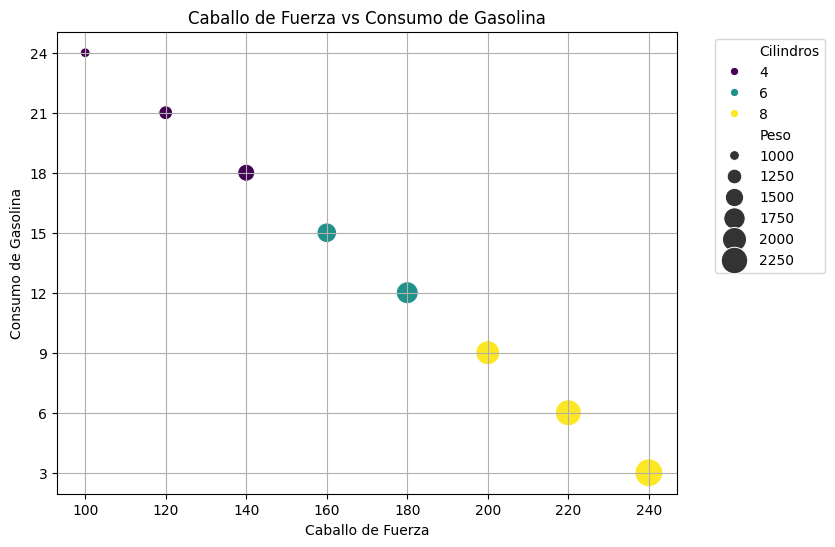

In [41]:
# Pandas, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe

data = {
    "Caballo_Fuerza": [100, 120, 140, 160, 180, 200, 220, 240],

    "Consumo_Gasolina": [24, 21, 18, 15, 12, 9, 6, 3],

    "Peso": [1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],

    "Cilindros": [4, 4, 4, 6, 6, 8, 8, 8]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")
print(df)


# 3. crear grafico de dispersion

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Caballo_Fuerza",
    y="Consumo_Gasolina",
    size="Peso",
    hue="Cilindros",
    palette="viridis",
    sizes=(50, 400)
)


# 4. personalizar grafico

plt.title("Caballo de Fuerza vs Consumo de Gasolina")

plt.xlabel("Caballo de Fuerza")

plt.ylabel("Consumo de Gasolina")

plt.xticks([100, 120, 140, 160, 180, 200, 220, 240])

plt.yticks([3, 6, 9, 12, 15, 18, 21, 24])

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.show()

DATAFRAME ORIGINAL
   Region  Ventas
0   Norte     215
1   Norte     196
2   Norte     219
3   Norte     246
4   Norte     193
5   Norte     193
6   Norte     247
7   Norte     223
8   Norte     186
9   Norte     216
10  Norte     186
11  Norte     186
12  Norte     207
13  Norte     143
14  Norte     148
15  Norte     183
16  Norte     170
17  Norte     209
18  Norte     173
19  Norte     158


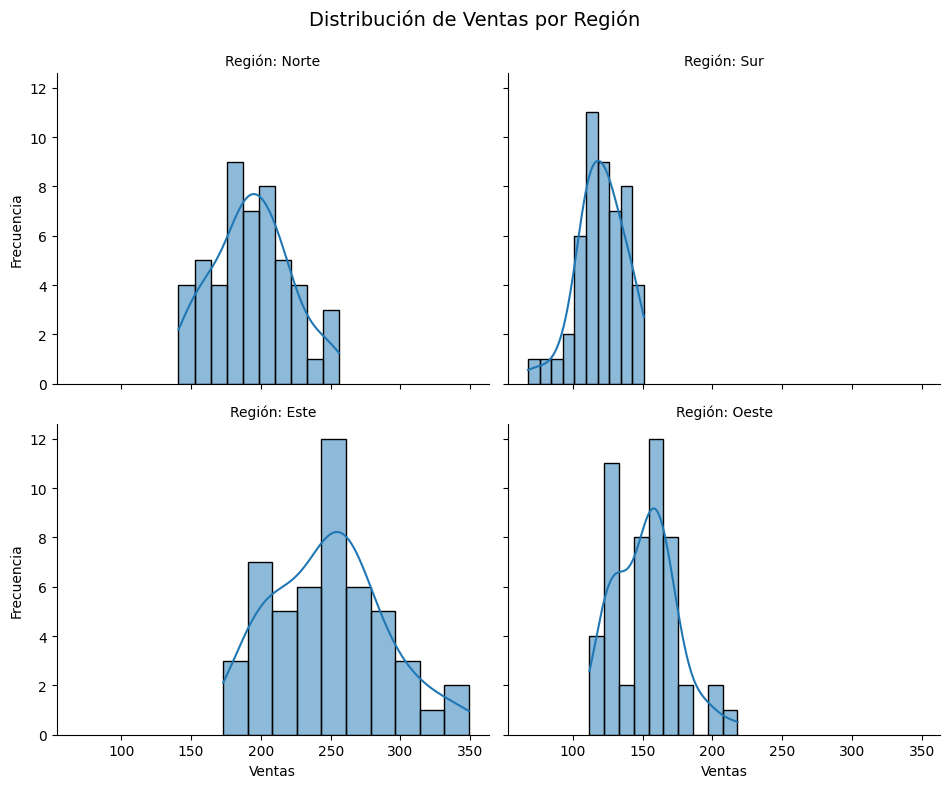

In [43]:
# Pandas, NumPy, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. generar datos

np.random.seed(42)

data = {
    "Region": (
        ["Norte"] * 50 +
        ["Sur"] * 50 +
        ["Este"] * 50 +
        ["Oeste"] * 50
    ),

    "Ventas": (
        list(np.random.normal(200, 30, 50)) +
        list(np.random.normal(120, 20, 50)) +
        list(np.random.normal(250, 40, 50)) +
        list(np.random.normal(150, 25, 50))
    )
}

df = pd.DataFrame(data)


# 3. convertir ventas a enteros

df["Ventas"] = df["Ventas"].round().astype(int)


# 4. mostrar dataframe

print("DATAFRAME ORIGINAL")

print(df.head(20))


# 5. crear cuadrícula de gráficos

g = sns.FacetGrid(
    df,
    col="Region",
    col_wrap=2,
    height=4,
    aspect=1.2
)


# 6. agregar histogramas con KDE

g.map_dataframe(
    sns.histplot,
    x="Ventas",
    kde=True,
    bins=10
)


# 7. personalizar gráficos

g.set_axis_labels(
    "Ventas",
    "Frecuencia"
)

g.set_titles(
    "Región: {col_name}"
)


# 8. título general

g.figure.suptitle(
    "Distribución de Ventas por Región",
    fontsize=14
)

g.figure.subplots_adjust(top=0.90)


# 9. mostrar gráfico

plt.show()

DATAFRAME ORIGINAL
   Edad  Ingresos  Gastos  Ahorros  Horas_Trabajo  Experiencia
0    22      1200     800      400             20            1
1    25      1500     900      600             25            2
2    28      1800    1000      800             30            3
3    30      2200    1200     1000             35            5
4    35      2600    1400     1200             40            7
5    40      3000    1600     1400             45           10
6    45      3400    1800     1600             50           12
7    50      3800    2000     1800             55           15
8    55      4200    2200     2000             60           18
9    60      4600    2400     2200             65           20
MATRIZ DE CORRELACION
                   Edad  Ingresos    Gastos   Ahorros  Horas_Trabajo  \
Edad           1.000000  0.996383  0.998042  0.992977       0.992977   
Ingresos       0.996383  1.000000  0.998953  0.999098       0.999098   
Gastos         0.998042  0.998953  1.000000  0.996

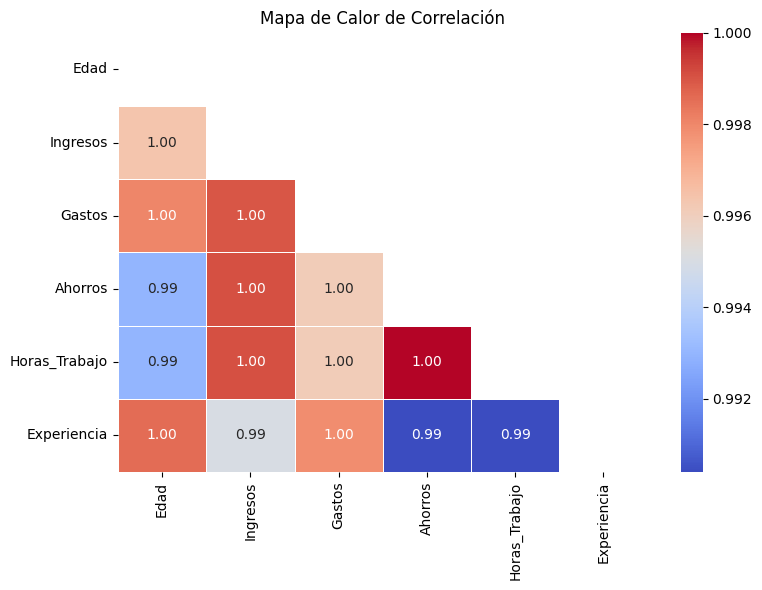

In [45]:
# Pandas, NumPy, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe con 6 variables numericas

data = {
    "Edad": [22, 25, 28, 30, 35, 40, 45, 50, 55, 60],

    "Ingresos": [1200, 1500, 1800, 2200, 2600, 3000, 3400, 3800, 4200, 4600],

    "Gastos": [800, 900, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],

    "Ahorros": [400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200],

    "Horas_Trabajo": [20, 25, 30, 35, 40, 45, 50, 55, 60, 65],

    "Experiencia": [1, 2, 3, 5, 7, 10, 12, 15, 18, 20]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")

print(df)


# 3. calcular matriz de correlacion

correlacion = df.corr()

print("MATRIZ DE CORRELACION")

print(correlacion)


# 4. crear mascara para mostrar solo la mitad inferior

mascara = np.triu(
    np.ones_like(correlacion, dtype=bool)
)


# 5. crear mapa de calor

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)


# 6. personalizar grafico

plt.title("Mapa de Calor de Correlación")

plt.tight_layout()

plt.show()

DATAFRAME ORIGINAL
     Empleado Nivel_Educativo  Salario
0         Ana         Tecnico     1800
1        Juan         Tecnico     2000
2       Pedro       Tecnologo     2400
3       Maria       Tecnologo     2600
4      Carlos       Tecnologo     2800
5       Laura   Universitario     3200
6      Andres   Universitario     3500
7       Sofia   Universitario     3700
8      Miguel        Maestria     4500
9   Valentina        Maestria     4800
10     Daniel       Doctorado     5500
11     Camila       Doctorado     6000

CANTIDAD DE EMPLEADOS POR NIVEL EDUCATIVO
Nivel_Educativo
Tecnologo        3
Universitario    3
Tecnico          2
Maestria         2
Doctorado        2
Name: count, dtype: int64


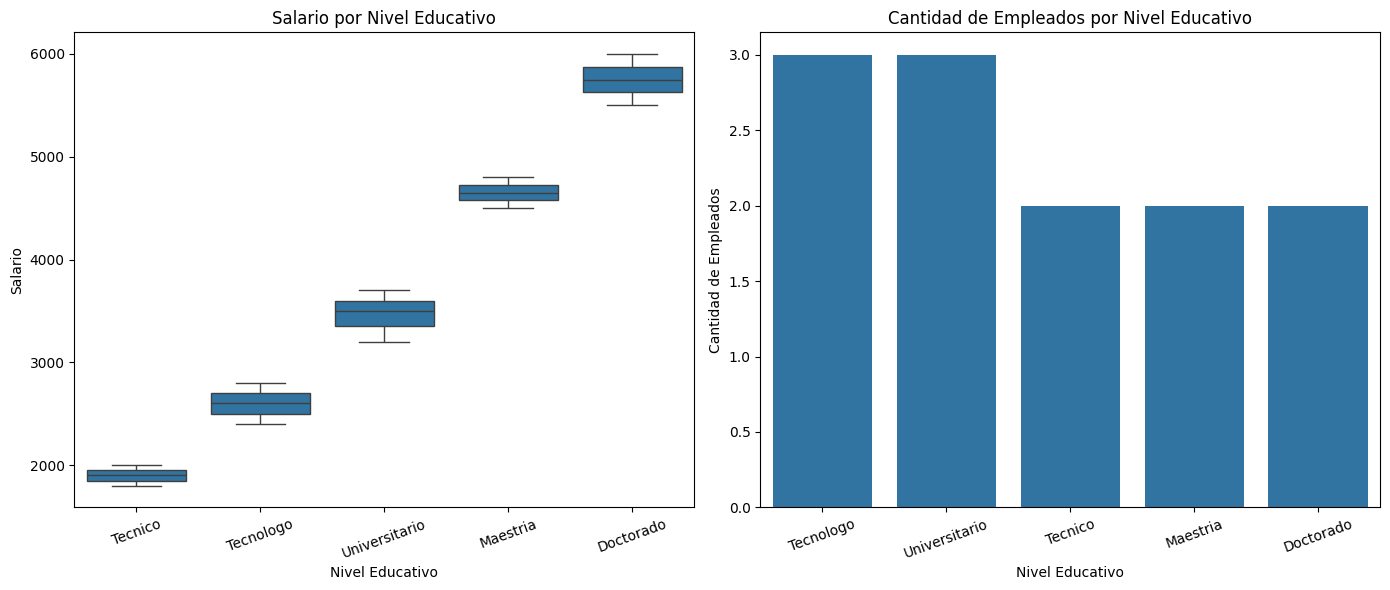

In [47]:
# Pandas, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe

data = {
    "Empleado": [
        "Ana", "Juan", "Pedro", "Maria", "Carlos",
        "Laura", "Andres", "Sofia", "Miguel", "Valentina",
        "Daniel", "Camila"
    ],

    "Nivel_Educativo": [
        "Tecnico", "Tecnico",
        "Tecnologo", "Tecnologo", "Tecnologo",
        "Universitario", "Universitario", "Universitario",
        "Maestria", "Maestria",
        "Doctorado", "Doctorado"
    ],

    "Salario": [
        1800, 2000,
        2400, 2600, 2800,
        3200, 3500, 3700,
        4500, 4800,
        5500, 6000
    ]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")

print(df)


# 3. contar empleados por nivel educativo

conteo = df["Nivel_Educativo"].value_counts()

print("\nCANTIDAD DE EMPLEADOS POR NIVEL EDUCATIVO")

print(conteo)


# 4. crear figura con 1 fila y 2 columnas

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# 5. boxplot de salarios por nivel educativo

sns.boxplot(
    data=df,
    x="Nivel_Educativo",
    y="Salario",
    ax=axes[0]
)

axes[0].set_title(
    "Salario por Nivel Educativo"
)

axes[0].set_xlabel(
    "Nivel Educativo"
)

axes[0].set_ylabel(
    "Salario"
)

axes[0].tick_params(
    axis="x",
    rotation=20
)


# 6. grafico de barras ordenado de mayor a menor

sns.barplot(
    x=conteo.index,
    y=conteo.values,
    ax=axes[1]
)

axes[1].set_title(
    "Cantidad de Empleados por Nivel Educativo"
)

axes[1].set_xlabel(
    "Nivel Educativo"
)

axes[1].set_ylabel(
    "Cantidad de Empleados"
)

axes[1].tick_params(
    axis="x",
    rotation=20
)


# 7. ajustar diseño

plt.tight_layout()


# 8. mostrar figura

plt.show()

DATAFRAME ORIGINAL
       Fecha  Ventas
0 2026-01-01     202
1 2026-01-02     448
2 2026-01-03     370
3 2026-01-04     206
4 2026-01-05     171

VENTAS MENSUALES
Mes
1      9697
2      8371
3      9761
4      9190
5      9178
6      7838
7     10411
8      8987
9      9691
10     8996
11     9808
12     8822
Name: Ventas, dtype: int64

PROMEDIO MENSUAL
9229.166666666666


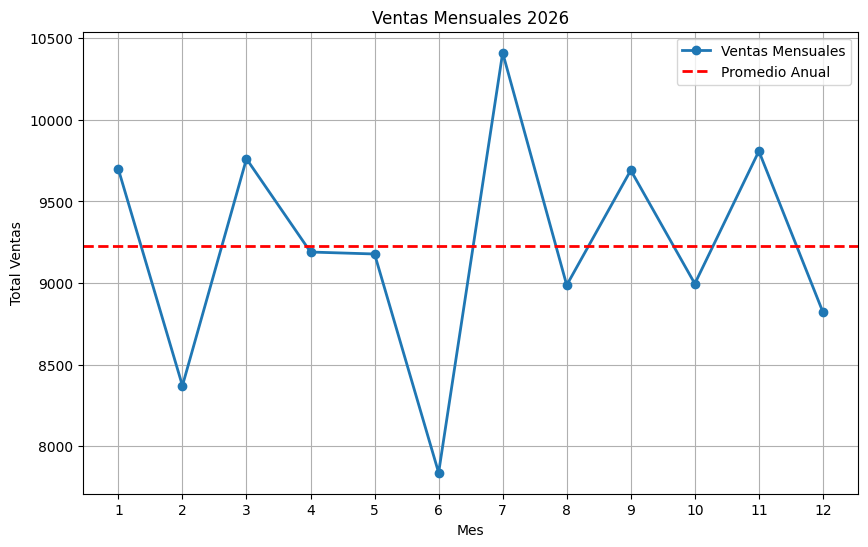

In [49]:
# Pandas, NumPy y Matplotlib

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 2. generar fechas de un año

fechas = pd.date_range(
    start="2026-01-01",
    end="2026-12-31",
    freq="D"
)


# 3. generar ventas diarias simuladas

np.random.seed(42)

ventas = np.random.randint(
    100,
    500,
    len(fechas)
)


# 4. crear dataframe

df = pd.DataFrame({
    "Fecha": fechas,
    "Ventas": ventas
})

print("DATAFRAME ORIGINAL")

print(df.head())


# 5. extraer mes

df["Mes"] = df["Fecha"].dt.month


# 6. agrupar ventas por mes

ventas_mensuales = df.groupby("Mes")["Ventas"].sum()

print("\nVENTAS MENSUALES")

print(ventas_mensuales)


# 7. calcular promedio mensual

promedio_mensual = ventas_mensuales.mean()

print("\nPROMEDIO MENSUAL")

print(promedio_mensual)


# 8. crear grafico

plt.figure(figsize=(10, 6))

plt.plot(
    ventas_mensuales.index,
    ventas_mensuales.values,
    marker="o",
    linewidth=2,
    label="Ventas Mensuales"
)


# 9. agregar linea de promedio

plt.axhline(
    y=promedio_mensual,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Promedio Anual"
)


# 10. personalizar grafico

plt.title("Ventas Mensuales 2026")

plt.xlabel("Mes")

plt.ylabel("Total Ventas")

plt.xticks(range(1, 13))

plt.legend()

plt.grid(True)


# 11. mostrar grafico

plt.show()

DATAFRAME ORIGINAL
    Puntaje_Credito  Deuda_Total Incumplio_Pago
0               502         4627             No
1               835        26939             Si
2               748        49925             Si
3               670        43941             No
4               506        22834             No
5               471        19047             No
6               588        27105             No
7               420        11230             No
8               502        16707             Si
9               521        22976             Si
10              614        45262             No
11              730        24776             No
12              487        31080             Si
13              772         2306             Si
14              499         7776             No
15              759        28251             No
16              551        10474             Si
17              530        41294             No
18              549        22959             No
19              708  

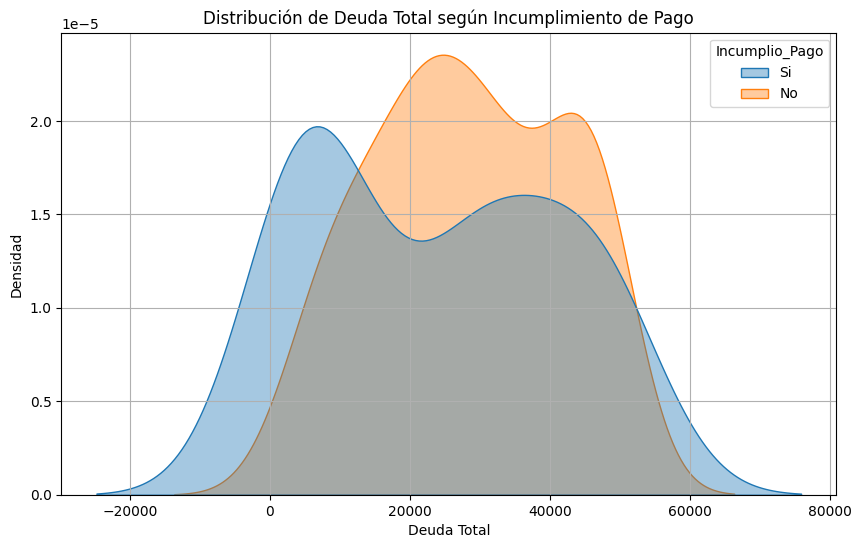

In [50]:
# Pandas, NumPy, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe

np.random.seed(42)

data = {
    "Puntaje_Credito": np.random.randint(400, 850, 200),

    "Deuda_Total": np.random.randint(1000, 50000, 200),

    "Incumplio_Pago": np.random.choice(
        ["Si", "No"],
        200,
        p=[0.3, 0.7]
    )
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")

print(df.head(20))


# 3. filtrar clientes con puntaje superior a 600

df_filtrado = df[
    df["Puntaje_Credito"] > 600
]

print("\nCLIENTES CON PUNTAJE > 600")

print(df_filtrado.head(20))


# 4. cantidad de clientes filtrados

print("\nTOTAL CLIENTES FILTRADOS")

print(len(df_filtrado))


# 5. crear grafico KDE

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_filtrado,
    x="Deuda_Total",
    hue="Incumplio_Pago",
    fill=True,
    common_norm=False,
    alpha=0.4
)


# 6. personalizar grafico

plt.title(
    "Distribución de Deuda Total según Incumplimiento de Pago"
)

plt.xlabel(
    "Deuda Total"
)

plt.ylabel(
    "Densidad"
)

plt.grid(True)


# 7. mostrar grafico

plt.show()

DATAFRAME ORIGINAL
   Estudiante  Porcentaje_Asistencia  Nota_Final      Materia
0         Ana                     95         4.8  Matematicas
1        Juan                     80         3.5  Matematicas
2       Pedro                     75         3.2  Matematicas
3       Maria                     90         4.5  Matematicas
4      Carlos                     60         2.8  Matematicas
5       Laura                     85         4.0       Fisica
6      Andres                     70         3.1       Fisica
7       Sofia                     98         5.0       Fisica
8      Miguel                     65         2.9       Fisica
9      Camila                     88         4.3       Fisica
10  Valentina                     92         4.7      Quimica
11     Daniel                     78         3.4      Quimica
12       Sara                     83         3.9      Quimica
13      Jorge                     72         3.0      Quimica
14      Luisa                     96         4.9   

/tmp/ipykernel_8290/1698688391.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlaciones = df.groupby("Materia").apply(


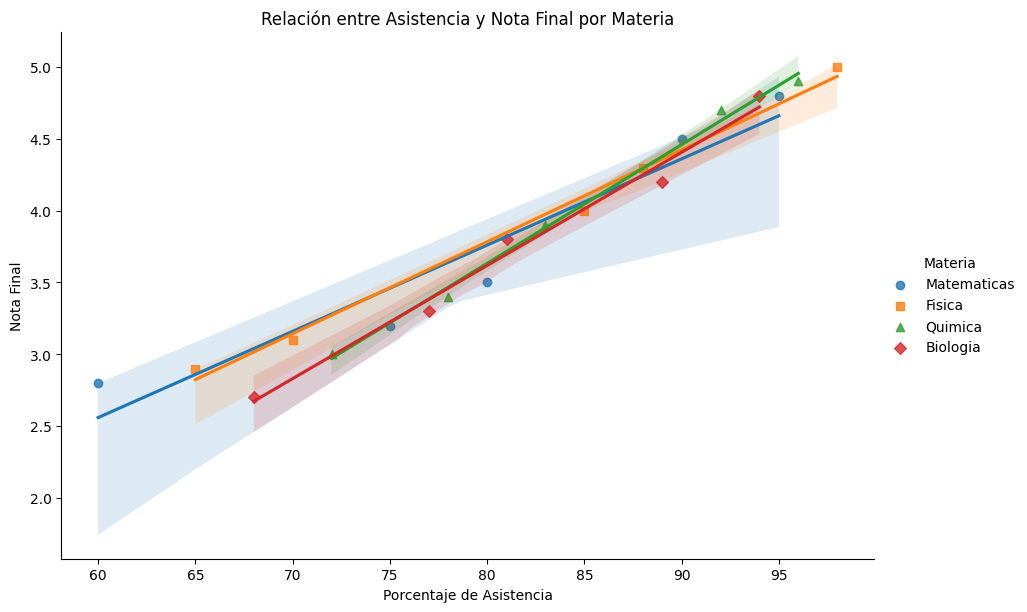

In [51]:
# Pandas, NumPy, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe

np.random.seed(42)

data = {
    "Estudiante": [
        "Ana","Juan","Pedro","Maria","Carlos",
        "Laura","Andres","Sofia","Miguel","Camila",
        "Valentina","Daniel","Sara","Jorge","Luisa",
        "David","Paula","Mateo","Juliana","Felipe"
    ],

    "Porcentaje_Asistencia": [
        95,80,75,90,60,
        85,70,98,65,88,
        92,78,83,72,96,
        68,89,77,94,81
    ],

    "Nota_Final": [
        4.8,3.5,3.2,4.5,2.8,
        4.0,3.1,5.0,2.9,4.3,
        4.7,3.4,3.9,3.0,4.9,
        2.7,4.2,3.3,4.8,3.8
    ],

    "Materia": [
        "Matematicas","Matematicas","Matematicas","Matematicas","Matematicas",
        "Fisica","Fisica","Fisica","Fisica","Fisica",
        "Quimica","Quimica","Quimica","Quimica","Quimica",
        "Biologia","Biologia","Biologia","Biologia","Biologia"
    ]
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")

print(df)


# 3. calcular correlacion por materia

print("\nCORRELACION DE PEARSON POR MATERIA")

correlaciones = df.groupby("Materia").apply(
    lambda x: x["Porcentaje_Asistencia"].corr(x["Nota_Final"])
)

print(correlaciones)


# 4. convertir correlaciones a dataframe

df_corr = correlaciones.reset_index()

df_corr.columns = [
    "Materia",
    "Correlacion_Pearson"
]

print("\nTABLA DE CORRELACIONES")

print(df_corr)


# 5. grafico de dispersion con linea de regresion

sns.lmplot(
    data=df,
    x="Porcentaje_Asistencia",
    y="Nota_Final",
    hue="Materia",
    height=6,
    aspect=1.5,
    markers=["o", "s", "^", "D"]
)


# 6. personalizar grafico

plt.title(
    "Relación entre Asistencia y Nota Final por Materia"
)

plt.xlabel(
    "Porcentaje de Asistencia"
)

plt.ylabel(
    "Nota Final"
)


# 7. mostrar grafico

plt.show()

DATAFRAME ORIGINAL
    Ciudad_Origen  Pasajeros
0          Bogota        910
1        Medellin       3822
2            Cali       3142
3    Barranquilla        516
4       Cartagena       4476
5     Bucaramanga       3494
6         Pereira       3221
7       Manizales       2969
8         Armenia        180
9           Pasto       1735
10          Tunja        819
11          Neiva       2441
12       Monteria       2483
13      Sincelejo       1234
14     Valledupar       4605
15  Villavicencio       3435
16        Popayan       4167
17         Ibague       4893
18       Riohacha       2954
19          Yopal        524
20      Florencia       1132
21         Quibdo       2608
22          Mocoa       2097
23        Leticia       2797
24         Arauca       1025
25         Cucuta       1856
26          Turbo        239
27       Rionegro       2784
28        La Ceja       3055
29       Envigado       4708
30          Bello       1949
31       Girardot       1317
32         Soacha       

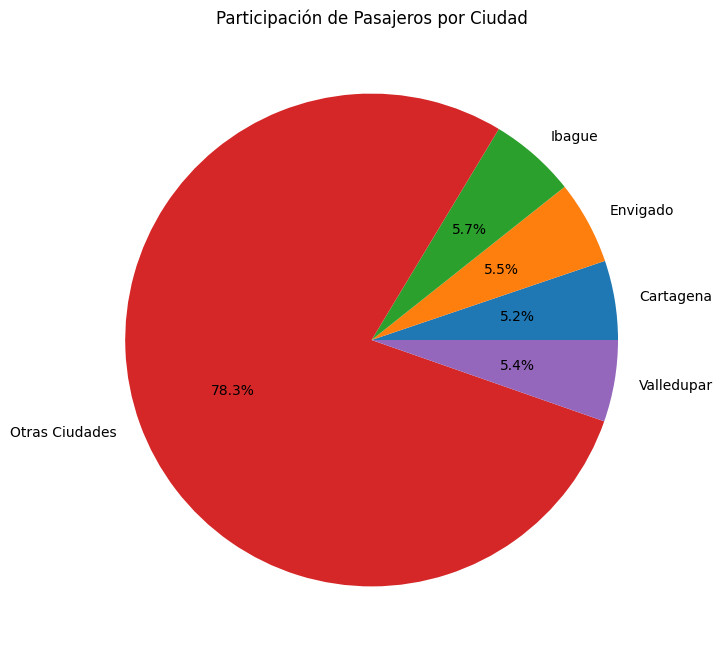

In [52]:
# Pandas, NumPy y Matplotlib

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 2. crear dataframe

np.random.seed(42)

ciudades = [
    "Bogota", "Medellin", "Cali", "Barranquilla", "Cartagena",
    "Bucaramanga", "Pereira", "Manizales", "Armenia", "Pasto",
    "Tunja", "Neiva", "Monteria", "Sincelejo", "Valledupar",
    "Villavicencio", "Popayan", "Ibague", "Riohacha", "Yopal",
    "Florencia", "Quibdo", "Mocoa", "Leticia", "Arauca",
    "Cucuta", "Turbo", "Rionegro", "La Ceja", "Envigado",
    "Bello", "Girardot", "Soacha", "Palmira", "Apartado"
]

pasajeros = np.random.randint(
    50,
    5000,
    len(ciudades)
)

df = pd.DataFrame({
    "Ciudad_Origen": ciudades,
    "Pasajeros": pasajeros
})

print("DATAFRAME ORIGINAL")

print(df)


# 3. calcular porcentaje de pasajeros

total_pasajeros = df["Pasajeros"].sum()

df["Porcentaje"] = (
    df["Pasajeros"] / total_pasajeros
) * 100

print("\nPORCENTAJE POR CIUDAD")

print(df)


# 4. reemplazar ciudades menores al 5%

df["Ciudad_Agrupada"] = np.where(
    df["Porcentaje"] < 5,
    "Otras Ciudades",
    df["Ciudad_Origen"]
)

print("\nCIUDADES AGRUPADAS")

print(df)


# 5. agrupar nuevamente

resumen = df.groupby(
    "Ciudad_Agrupada"
)["Pasajeros"].sum()

print("\nRESUMEN FINAL")

print(resumen)


# 6. crear grafico de torta

plt.figure(figsize=(8, 8))

plt.pie(
    resumen,
    labels=resumen.index,
    autopct="%1.1f%%"
)

plt.title(
    "Participación de Pasajeros por Ciudad"
)

plt.show()

DATAFRAME ORIGINAL
   Dia_Semana     Genero  Gasto_Total
0     Domingo  Masculino           67
1      Jueves   Femenino          108
2     Viernes  Masculino          256
3     Domingo  Masculino          392
4   Miercoles  Masculino          404
5     Viernes   Femenino          291
6     Viernes   Femenino          208
7     Domingo  Masculino          211
8      Martes   Femenino          466
9   Miercoles  Masculino           88
10    Domingo  Masculino          297
11  Miercoles   Femenino          368
12  Miercoles   Femenino          266
13    Viernes  Masculino          470
14     Jueves   Femenino           95
15  Miercoles   Femenino          173
16     Sabado  Masculino          163
17    Viernes  Masculino          454
18     Martes   Femenino          105
19     Jueves  Masculino          204

REGISTROS POR DIA
Dia_Semana
Jueves       53
Domingo      47
Lunes        45
Sabado       41
Miercoles    41
Viernes      37
Martes       36
Name: count, dtype: int64


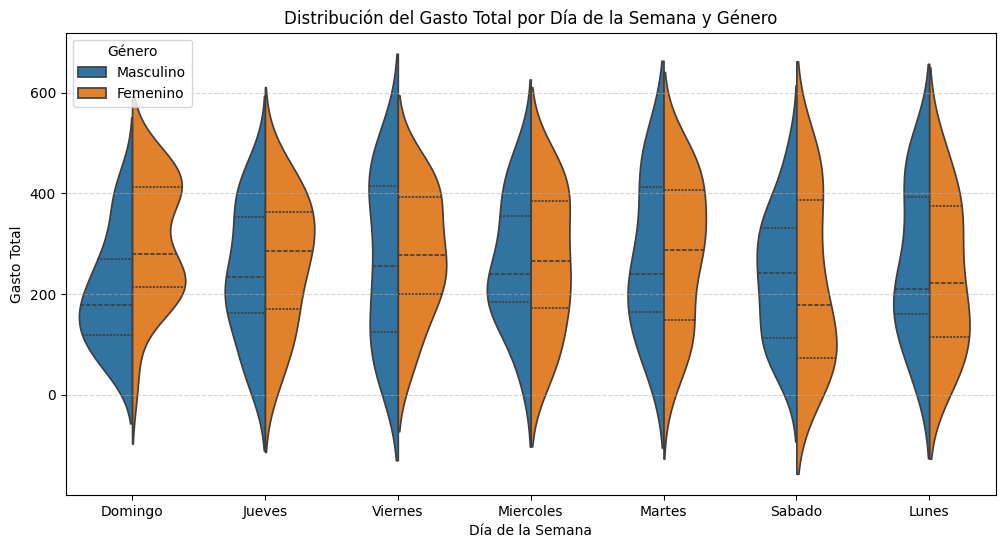

In [53]:
# Pandas, NumPy, Matplotlib y Seaborn

# 1. importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. crear dataframe

np.random.seed(42)

dias = [
    "Lunes", "Martes", "Miercoles",
    "Jueves", "Viernes", "Sabado", "Domingo"
]

data = {
    "Dia_Semana": np.random.choice(
        dias,
        300
    ),

    "Genero": np.random.choice(
        ["Masculino", "Femenino"],
        300
    ),

    "Gasto_Total": np.random.randint(
        20,
        500,
        300
    )
}

df = pd.DataFrame(data)

print("DATAFRAME ORIGINAL")

print(df.head(20))


# 3. cantidad de registros por dia

print("\nREGISTROS POR DIA")

print(df["Dia_Semana"].value_counts())


# 4. crear grafico violin split

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Dia_Semana",
    y="Gasto_Total",
    hue="Genero",
    split=True,
    inner="quartile"
)


# 5. personalizar grafico

plt.title(
    "Distribución del Gasto Total por Día de la Semana y Género"
)

plt.xlabel(
    "Día de la Semana"
)

plt.ylabel(
    "Gasto Total"
)

plt.legend(
    title="Género"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


# 6. mostrar grafico

plt.show()